# Let's compute the Scaling Behavior of Bellman Ford Shortest Path Algorithm
In this activity, we'll build random graphs of different sizes and measure the performance of the Bellman-Ford algorithm on them. However, there is a wrinkle. Instead of [using `VLDataScienceMachineLearningPackage.jl`](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), we'll use [the `Graphs.jl` package](https://github.com/JuliaGraphs/Graphs.jl) directly to create and manipulate our graphs. 

> __Why Graphs.jl?__ This is yet another example of the __buy versus build__ tradeoff. [The `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl) provides a high-level interface for working with graphs, including functions for creating, manipulating, and traversing them. However, we could also use existing packages [like `Graphs.jl`](https://github.com/JuliaGraphs/Graphs.jl) to achieve similar results (and perhaps do other things). Let's check out this package!

So let's go!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

The [include command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

In [1]:
include(joinpath(@__DIR__, "Include-ShortestPath-Graded-Codio.jl"));

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types and data used in this material. 

## Task 1: Let's use Graphs.jl to build and visualize a collection of random graphs
In this task, let's use [the `Graphs.jl` package](https://github.com/JuliaGraphs/Graphs.jl) to create some random graphs, and [the `Karnak.jl` package](https://github.com/cormullion/Karnak.jl) to visualize them. 

In [2]:
graph_collection_dictionary = let

    # initialize -
    graph_collection_dictionary = Dict{Tuple{Int,Int}, AbstractGraph}();
    n = 10:10:100 |> collect;
    k = 2:2:10 |> collect;
    isdirected = false;

    for i ∈ eachindex(n)
        for j ∈ eachindex(k)            
            # build graph -
            g = barabasi_albert(n[i], k[j], is_directed = isdirected);

            # store in dictionary -
            graph_collection_dictionary[(n[i], k[j])] = g;
        end
    end

    # check: sometimes, we get nodes with no edges, get rid of these cases
    for (key, g) ∈ graph_collection_dictionary
        if ne(g) == 0 # where is ne(g) defined?
            delete!(graph_collection_dictionary, key);
        end
    end

    graph_collection_dictionary; # return
end

Dict{Tuple{Int64, Int64}, AbstractGraph} with 49 entries:
  (20, 4)   => SimpleGraph{Int64}(64, [[5, 6, 7, 16, 18], [5, 6, 7, 14], [5, 15…
  (90, 6)   => SimpleGraph{Int64}(504, [[7, 8, 9, 10, 11, 12, 13, 19, 20, 21  ……
  (50, 8)   => SimpleGraph{Int64}(336, [[9, 10, 11, 13, 15, 18, 22, 23, 24, 25,…
  (50, 10)  => SimpleGraph{Int64}(400, [[11, 14, 15, 16, 17, 21, 22, 26, 27, 29…
  (10, 8)   => SimpleGraph{Int64}(16, [[9, 10], [9, 10], [9, 10], [9, 10], [9, …
  (50, 2)   => SimpleGraph{Int64}(96, [[3, 4, 9, 14, 15, 17, 21, 26, 30, 38, 39…
  (10, 2)   => SimpleGraph{Int64}(16, [[3, 5], [3, 4, 5], [1, 2, 4, 6, 7, 8, 9,…
  (70, 4)   => SimpleGraph{Int64}(264, [[5, 6, 10, 12, 13, 18, 22, 24, 27], [5,…
  (100, 8)  => SimpleGraph{Int64}(736, [[9, 10, 11, 12, 13, 14, 16, 18, 20, 29 …
  (100, 10) => SimpleGraph{Int64}(900, [[11, 12, 13, 14, 15, 17, 19, 24, 26, 34…
  (20, 8)   => SimpleGraph{Int64}(96, [[9, 10, 11, 14], [9, 11], [9, 10, 11, 12…
  (100, 2)  => SimpleGraph{Int64}(196, [[3, 20], [3

Now, let's select a random graph, and visualize it.

In [3]:
g = keys(graph_collection_dictionary) |> collect |> rand |> i-> graph_collection_dictionary[i]

{70, 264} undirected simple Int64 graph

We've seen the fields of the graph model implemented in [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), what fields are in the graph models exported by [the `Graphs.jl` package](https://github.com/JuliaGraphs/Graphs.jl)?

In [4]:
typeof(g) |> T -> fieldnames(T)

(:ne, :fadjlist)

Let's dig into the fields of the graph model `g`.
* __ne::Int64:__ is the number of edges contained in the random graph `g <: AbstractGraph`, i.e., the graph `g` is a subtype of `AbstractGraph`, either a `SimpleGraph` in undirected, or a `SimpleDiGraph` if directed.
* __fadjlist::Array{Array{Int64}}:__ is an array of `Array{Int64}` types, i.e., an array of arrays, where the array at element $i$ holds the list of children of node $i$. Thus, if we wanted to check for a parent-child relationship between node $i$ and node $j$, we could see if node $j$ was an element of the children list of node $i$. I wish it where a `Set{Int64}` instead of an array, but perhaps that is just me.

In [22]:
g.fadjlist # what is this?

70-element Vector{Vector{Int64}}:
 [5, 6, 10, 12, 13, 18, 22, 24, 27]
 [5, 7, 8, 10, 12, 16, 19, 22, 24, 25, 49, 50, 53, 55, 61, 66]
 [5, 6, 7, 8, 9, 10, 11, 16, 17, 20, 27, 38, 43, 44, 51, 55]
 [5, 6, 21, 46, 59]
 [1, 2, 3, 4, 6, 7, 8, 14, 15, 17, 18, 24, 31, 34, 41, 43, 46, 58, 60, 69]
 [1, 3, 4, 5, 7, 8, 9, 14, 18, 19  …  40, 47, 48, 51, 53, 54, 56, 59, 60, 66]
 [2, 3, 5, 6, 9, 10, 14, 16, 17, 18, 23, 28, 31, 32, 33, 36, 49, 64, 68]
 [2, 3, 5, 6, 9, 11, 12, 14, 15, 19, 25, 28, 29, 32, 36, 49, 52, 57, 62]
 [3, 6, 7, 8, 11, 13, 20, 21, 24, 26, 28, 30, 33, 49, 64]
 [1, 2, 3, 7, 11, 12, 13, 15, 17, 21  …  32, 44, 45, 46, 47, 48, 51, 61, 63, 64]
 ⋮
 [8, 17, 31, 58, 67]
 [10, 28, 40, 54]
 [7, 9, 10, 11]
 [20, 49, 51, 60]
 [2, 6, 19, 20]
 [15, 32, 54, 62]
 [7, 12, 33, 39, 70]
 [5, 20, 37, 39]
 [27, 42, 47, 68]

`Unhide` the code block below to see how we visualized the random graph selected from our collection of graphs [using the `Karnak.jl` package](https://github.com/cormullion/Karnak.jl).

> __Caution:__ The [`Karnak.jl` package](https://github.com/cormullion/Karnak.jl) uses some advanced features of the Julia programming language, e.g., [macros](https://docs.julialang.org/en/v1/manual/metaprogramming/#man-macros), which may not be familiar to all users. This example also uses some next generation syntax, so don't be confused if you see something you don't recognize!

While a little complicated, this package produces some cool visualizations of graphs!

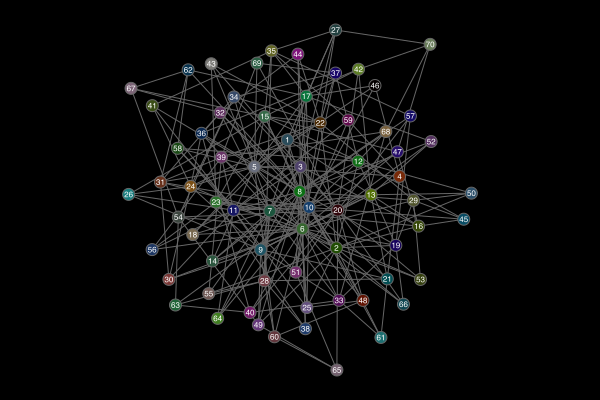

In [6]:
let
    @drawsvg begin
    background("black")
    sethue("grey40")
    fontsize(8)
    drawgraph(g, 
        layout=stress, 
        vertexlabels = 1:nv(g),
        vertexfillcolors = 
            [RGB(rand()/2, rand()/2, rand()/2) 
               for i in 1:nv(g)]
    )
    end 600 400
end

## Task 2: Let's compute the short path on our random graph
In this task, we'll compute the shortest path to all other nodes starting from node `1` using the Bellman-Ford algorithm. However, unlike our previous examples that used [the `findshortestpath(...)` function exported by the `VLDataScienceMachineLearningPackage.jl` package ](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/graphs/#VLDataScienceMachineLearningPackage.findshortestpath), we will call [the `bellman_ford_shortest_paths(...)` function from the `Graphs.jl` package](https://juliagraphs.org/Graphs.jl/stable/algorithms/shortestpaths/#Graphs.bellman_ford_shortest_paths-Union{Tuple{T},%20Tuple{U},%20Tuple{AbstractGraph{U},%20AbstractVector{%3C:Integer}},%20Tuple{AbstractGraph{U},%20AbstractVector{%3C:Integer},%20AbstractMatrix{T}}}%20where%20{U%3C:Integer,%20T%3C:Number}).

This implementation takes a graph instance, and a start node index. However, this method returns a more complicated data structure that includes not only the distances but also the predecessor information for each node, which can be used to reconstruct the shortest paths which is an instance of type [`Graphs.BellmanFordState{Int64, Int64}`](https://juliagraphs.org/Graphs.jl/stable/algorithms/shortestpaths/#Graphs.BellmanFordState). 

Let's run the shortest path calculation, and save the result in the `result::Graphs.BellmanFordState{Int64, Int64}` variable.

In [14]:
result = bellman_ford_shortest_paths(g, 1);

What are the fields of the `Graphs.BellmanFordState{Int64, Int64}` type?

In [15]:
typeof(result) |> T -> fieldnames(T)

(:parents, :dists)

Let's dig into the fields of the `result` variable.
* __parents::Array{Int64,1}:__ The parents field hold the predecessor information for each node, which can be used to reconstruct the shortest paths. For example, the first node (at index `1`) has no parent (it is the source node), so it's parent is `0`. However, node `2` is a child of node `5` on the shortest path. The `parents` array can be used to trace back the shortest path from any node to the source node, and should have the same length as the number of nodes in the graph.
* __dists::Array{Int64,1}:__ The dists field holds the shortest path distances from the source node to each other node. If a node is unreachable from the source, its distance will be set to `Inf`. For example, from node `1` to node `1` has a distance of `0`, while from node `1` to node `2` has a distance of `2`, etc.


In [20]:
result.dists

70-element Vector{Int64}:
 0
 2
 2
 2
 1
 1
 2
 2
 2
 1
 ⋮
 3
 2
 2
 3
 2
 3
 2
 2
 2

__Check:__ If a node has a distance of `1` from the source node, it means that it is directly connected to the source node by an edge with a weight of `1`. We can check this by looking at the graph structure and the weights of the edges.